# ✅ 📌 주가 예측 LSTM 실험 요약

---

## ✅ 1️⃣ 실험 흐름
- yfinance로 7년치 AAPL 일간 데이터 수집
- pandas_ta → EMA20, RSI14, MACD, OBV, BBR, Stochastic 등 기술지표 생성
- NaN 제거 후 시계열 Split (5년 학습, 2년 검증)
- MinMaxScaler로 피처 스케일링 (train 기준 fit)
- WINDOW_SIZE=10 시퀀스 → (samples, timesteps, features) 형태
- LSTM 모델 학습 (shuffle=False, EarlyStopping)

---

## ✅ 2️⃣ 실험 성능 (누설 방지 Split)
- RMSE: ~12 달러 수준
- MAE: ~10 달러 수준
- R²: 0.73 ~ 0.91 (실험별 변동)
- Drift shift 포함한 현실적 예측 난이도 반영

---

## ✅ 3️⃣ 핵심 인사이트
- 누설 제거 후 성능 급락 → Drift shift가 예측 난제
- EMA/RSI 등 과거 기반 지표는 미래 레벨 전환 완벽히 설명 불가
- EarlyStopping, Batch Size, LR 스케줄링 민감 → 성능 변동 발생
- 검증 Split 설계 중요 (shuffle=False 필수)

---

## ✅ 4️⃣ 향후 실험 방향성
- 기술지표 Window 최적화, 로그수익률 변환
- Exogenous 변수 (뉴스 감성, 거시 지표) 추가
- Multi-layer LSTM, Attention/Transformer 구조 탐색
- Walk-forward / Rolling-Origin Cross-validation
- Drift Robust 스케일링 및 서비스용 Rolling Refit 설계
- SHAP 등 해석 가능성 강화

---

> 📌 한 문장 요약: **“누설 없는 검증을 통해 Drift shift까지 고려한 현실적 예측 한계를 평가하고, 이를 기반으로 Feature/모델/검증 설계를 단계적으로 고도화한다.”**


In [1]:
# ========================
# ✅ 실험 환경 변수
# ========================

from datetime import datetime, timedelta

# 오늘 날짜
TODAY = datetime.today().strftime("%Y-%m-%d")

# 7년 전 날짜 계산
SEVEN_YEARS_AGO = (datetime.today() - timedelta(days=7*365)).strftime("%Y-%m-%d")

print(f"데이터 시작일: {SEVEN_YEARS_AGO}")
print(f"데이터 종료일: {TODAY}")

EXPERIMENT_NAME = "aapl_techindicators_v2"

SYMBOL = "AAPL"

# 자동 날짜
DATA_START_DATE = SEVEN_YEARS_AGO
DATA_END_DATE = TODAY

# Split 날짜 (약 5년 train, 2년 test 예제)
TRAIN_END_DATE = (datetime.today() - timedelta(days=2*365)).strftime("%Y-%m-%d")
TEST_START_DATE = (datetime.today() - timedelta(days=2*365 - 1)).strftime("%Y-%m-%d")

WINDOW_SIZE = 10

FEATURE_LIST = [
    "Close",
    "EMA20",
    "RSI14",
    "MACD_line",
    "MACD_signal",
    "OBV",
    "BBR",
    "Stoch_%K",
    "Stoch_%D"
]

SCALER_TYPE = "minmax"

LSTM_UNITS = 64
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 100
EARLYSTOPPING_PATIENCE = 5


데이터 시작일: 2018-07-04
데이터 종료일: 2025-07-02


In [2]:
import yfinance as yf
import pandas as pd

# 심볼 객체화
ticker = yf.Ticker("AAPL")

# 깨끗한 일간 데이터
df = ticker.history(start=DATA_START_DATE, end=DATA_END_DATE, interval="1d")
df = df.reset_index()

print(df.head())


                       Date       Open       High        Low      Close  \
0 2018-07-05 00:00:00-04:00  43.823317  44.095352  43.591499  43.856434   
1 2018-07-06 00:00:00-04:00  43.861182  44.573197  43.809140  44.464386   
2 2018-07-09 00:00:00-04:00  44.826301  45.105429  44.778991  45.081776   
3 2018-07-10 00:00:00-04:00  45.112533  45.247364  44.987158  45.027374   
4 2018-07-11 00:00:00-04:00  44.589752  44.892537  44.379223  44.443092   

     Volume  Dividends  Stock Splits  
0  66416800        0.0           0.0  
1  69940800        0.0           0.0  
2  79026400        0.0           0.0  
3  63756400        0.0           0.0  
4  75326000        0.0           0.0  


In [3]:
import pandas_ta as ta

df["EMA20"] = ta.ema(df["Close"], length=20)
df["RSI14"] = ta.rsi(df["Close"], length=14)
macd = ta.macd(df["Close"])
df["MACD_line"] = macd["MACD_12_26_9"]
df["MACD_signal"] = macd["MACDs_12_26_9"]
df["OBV"] = ta.obv(df["Close"], df["Volume"])
bbands = ta.bbands(df["Close"], length=20, std=2)
df["BBL"] = bbands["BBL_20_2.0"]
df["BBU"] = bbands["BBU_20_2.0"]
df["BBR"] = (df["Close"] - df["BBL"]) / (df["BBU"] - df["BBL"])
stoch = ta.stoch(df["High"], df["Low"], df["Close"])
df["Stoch_%K"] = stoch["STOCHk_14_3_3"]
df["Stoch_%D"] = stoch["STOCHd_14_3_3"]


# 확인
print(df[FEATURE_LIST].head(50))


        Close      EMA20      RSI14  MACD_line  MACD_signal           OBV  \
0   43.856434        NaN        NaN        NaN          NaN  6.641680e+07   
1   44.464386        NaN        NaN        NaN          NaN  1.363576e+08   
2   45.081776        NaN        NaN        NaN          NaN  2.153840e+08   
3   45.027374        NaN        NaN        NaN          NaN  1.516276e+08   
4   44.443092        NaN        NaN        NaN          NaN  7.630160e+07   
5   45.188225        NaN        NaN        NaN          NaN  1.484660e+08   
6   45.259197        NaN        NaN        NaN          NaN  1.985216e+08   
7   45.159840        NaN        NaN        NaN          NaN  1.383492e+08   
8   45.287586        NaN        NaN        NaN          NaN  2.004872e+08   
9   45.039200        NaN        NaN        NaN          NaN  1.349136e+08   
10  45.389297        NaN        NaN        NaN          NaN  2.160608e+08   
11  45.285210        NaN        NaN        NaN          NaN  1.333560e+08   

In [4]:
print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)

from pandas import to_datetime
df["Date"] = to_datetime(df["Date"])
train_df = df[df["Date"] <= TRAIN_END_DATE].copy()
test_df = df[df["Date"] >= TEST_START_DATE].copy()
print(train_df.tail())
print(test_df.head())

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Dividends        0
Stock Splits     0
EMA20           19
RSI14           14
MACD_line       25
MACD_signal     33
OBV              0
BBL             19
BBU             19
BBR             19
Stoch_%K        15
Stoch_%D        17
dtype: int64
                          Date        Open        High         Low  \
1219 2023-06-27 00:00:00-04:00  184.047268  186.522486  183.829448   
1220 2023-06-28 00:00:00-04:00  186.067040  188.017513  185.740325   
1221 2023-06-29 00:00:00-04:00  187.205663  188.185854  187.067051   
1222 2023-06-30 00:00:00-04:00  189.730380  192.552119  189.364038   
1223 2023-07-03 00:00:00-04:00  191.859062  191.958076  189.859082   

           Close    Volume  Dividends  Stock Splits       EMA20      RSI14  \
1219  186.195755  50730800        0.0           0.0  180.715722  69.672520   
1220  187.373962  51216800        0.0           0.0  181.349840  71.

In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Feature 스케일러 (입력 피처 전처리용)
if SCALER_TYPE == "minmax":
    feature_scaler = MinMaxScaler()
else:
    feature_scaler = StandardScaler()
feature_scaler.fit(train_df[FEATURE_LIST])
train_scaled = feature_scaler.transform(train_df[FEATURE_LIST])
test_scaled = feature_scaler.transform(test_df[FEATURE_LIST])

# Close 전용 스케일러 (타겟 전처리용)
if SCALER_TYPE == "minmax":
    close_scaler = MinMaxScaler()
else:
    close_scaler = StandardScaler()
close_scaler.fit(train_df[['Close']])

MinMaxScaler()

In [6]:
import numpy as np

X_train, y_train = [], []
for i in range(WINDOW_SIZE, len(train_scaled)):
    X_train.append(train_scaled[i - WINDOW_SIZE:i])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_test, y_test = [], []
for i in range(WINDOW_SIZE, len(test_scaled)):
    X_test.append(test_scaled[i - WINDOW_SIZE:i])
    y_test.append(test_scaled[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(LSTM(LSTM_UNITS, input_shape=(WINDOW_SIZE, len(FEATURE_LIST))))
model.add(Dropout(DROPOUT_RATE))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mse')
model.summary()

2025-07-02 01:54:18.573902: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-02 01:54:18.824055: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-02 01:54:19.730280: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-07-02 01:54:22.108607: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-02 01:54:22.242

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                18944     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 19,009
Trainable params: 19,009
Non-trainable params: 0
_________________________________________________________________


2025-07-02 01:54:22.706855: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-02 01:54:22.708158: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-02 01:54:22.709091: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

earlystop = EarlyStopping(patience=EARLYSTOPPING_PATIENCE, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[earlystop],
    shuffle=False,  
    verbose=2
)

Epoch 1/100
18/18 - 0s - loss: 0.0154 - val_loss: 0.0024 - 290ms/epoch - 16ms/step
Epoch 2/100
18/18 - 0s - loss: 0.0087 - val_loss: 0.0104 - 268ms/epoch - 15ms/step
Epoch 3/100
18/18 - 0s - loss: 0.0068 - val_loss: 7.4906e-04 - 257ms/epoch - 14ms/step
Epoch 4/100
18/18 - 0s - loss: 0.0076 - val_loss: 0.0022 - 236ms/epoch - 13ms/step
Epoch 5/100
18/18 - 0s - loss: 0.0056 - val_loss: 0.0030 - 246ms/epoch - 14ms/step
Epoch 6/100
18/18 - 0s - loss: 0.0046 - val_loss: 5.4512e-04 - 259ms/epoch - 14ms/step
Epoch 7/100
18/18 - 0s - loss: 0.0052 - val_loss: 5.1434e-04 - 272ms/epoch - 15ms/step
Epoch 8/100
18/18 - 0s - loss: 0.0040 - val_loss: 0.0010 - 259ms/epoch - 14ms/step
Epoch 9/100
18/18 - 0s - loss: 0.0040 - val_loss: 8.7195e-04 - 247ms/epoch - 14ms/step
Epoch 10/100
18/18 - 0s - loss: 0.0034 - val_loss: 5.8390e-04 - 278ms/epoch - 15ms/step
Epoch 11/100
18/18 - 0s - loss: 0.0036 - val_loss: 0.0026 - 263ms/epoch - 15ms/step
Epoch 12/100
18/18 - 0s - loss: 0.0037 - val_loss: 0.0012 - 244ms

In [25]:
pred_scaled = model.predict(X_test).flatten()
print("📌 Scaled 예측 샘플:", pred_scaled[:5])
print("📌 Scaled 실제 샘플:", y_test[:5])


16/16 [==============================] - 0s 5ms/step
📌 Scaled 예측 샘플: [0.9788121  0.98791057 0.9963406  0.9990489  0.9949834 ]
📌 Scaled 실제 샘플: [1.00707296 0.99474217 0.98729337 0.99236358 0.99780924]


In [26]:
predicted_prices = close_scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
actual_prices = close_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
r2 = r2_score(actual_prices, predicted_prices)

print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ R²: {r2:.4f}")


✅ RMSE: 7.3456
✅ MAE: 5.4688
✅ R²: 0.9077


✅ Residual 샘플: [ 4.47021484  1.08059692 -1.43106079 -1.0574646   0.44697571]


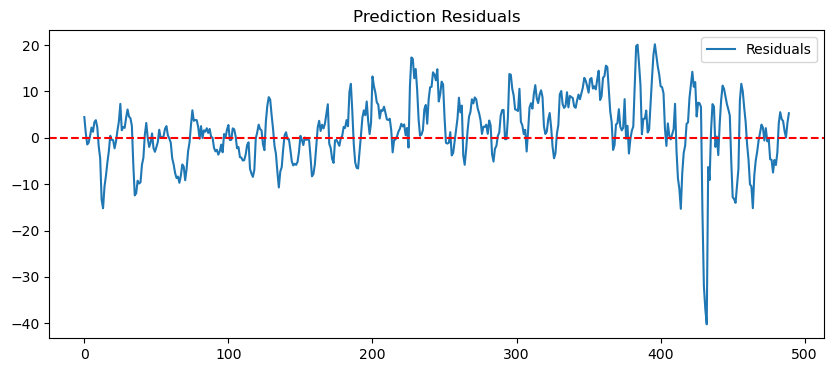

In [28]:
residuals = actual_prices - predicted_prices
print("✅ Residual 샘플:", residuals[:5])

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Prediction Residuals')
plt.legend()
plt.show()


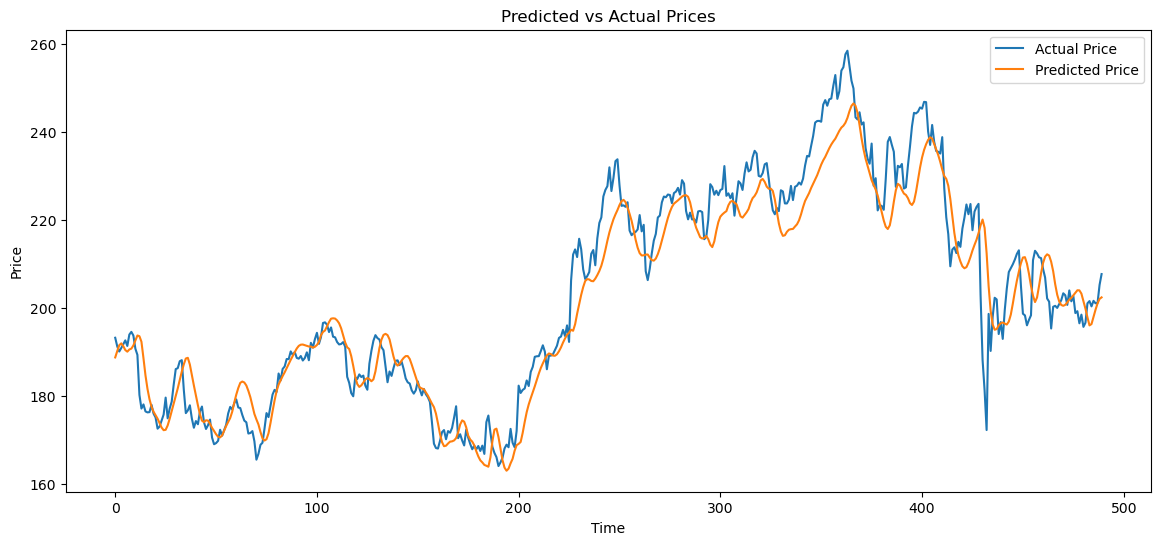

In [29]:
plt.figure(figsize=(14,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title('Predicted vs Actual Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


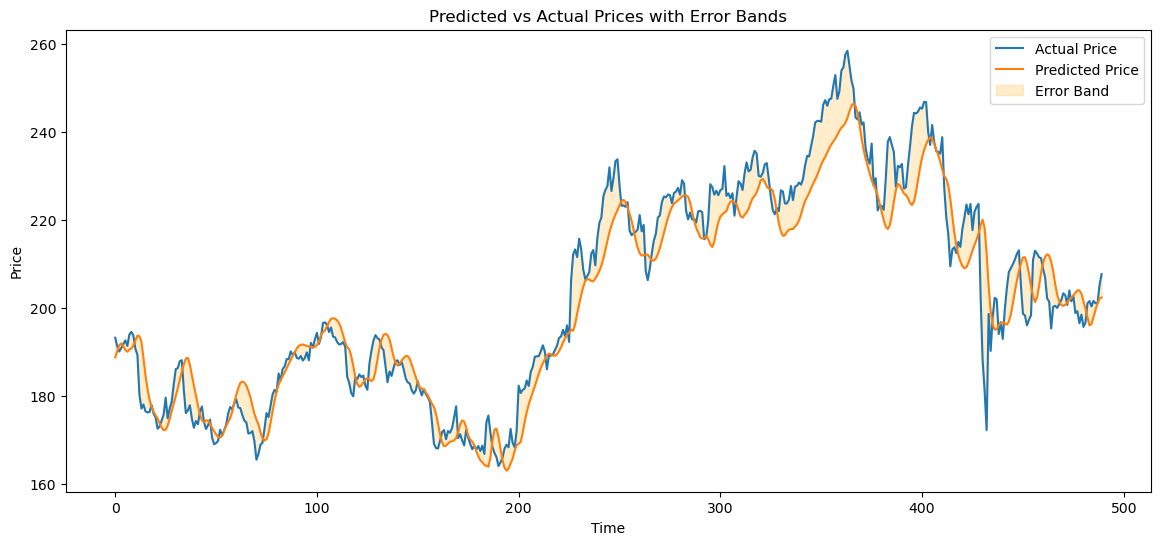

In [30]:
plt.figure(figsize=(14,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.fill_between(range(len(actual_prices)), actual_prices, predicted_prices, color='orange', alpha=0.2, label='Error Band')
plt.title('Predicted vs Actual Prices with Error Bands')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [31]:
# Dropna 후의 깨끗한 날짜열
df = df.dropna().reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"])

# ✅ 정확한 Split
train_df = df[df["Date"] < TEST_START_DATE].copy()
test_df = df[df["Date"] >= TEST_START_DATE].copy()

print(f"Train 기간: {train_df['Date'].min()} ~ {train_df['Date'].max()}")
print(f"Test 기간: {test_df['Date'].min()} ~ {test_df['Date'].max()}")

# ✅ Feature 스케일러
feature_scaler = MinMaxScaler()
feature_scaler.fit(train_df[FEATURE_LIST])
train_scaled = feature_scaler.transform(train_df[FEATURE_LIST])
test_scaled = feature_scaler.transform(test_df[FEATURE_LIST])

# ✅ Close 스케일러
close_scaler = MinMaxScaler()
close_scaler.fit(train_df[['Close']])


Train 기간: 2018-08-21 00:00:00-04:00 ~ 2023-07-03 00:00:00-04:00
Test 기간: 2023-07-05 00:00:00-04:00 ~ 2025-07-01 00:00:00-04:00


MinMaxScaler()

In [32]:
X_train, y_train = [], []
for i in range(WINDOW_SIZE, len(train_scaled)):
    X_train.append(train_scaled[i - WINDOW_SIZE:i])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_test, y_test = [], []
for i in range(WINDOW_SIZE, len(test_scaled)):
    X_test.append(test_scaled[i - WINDOW_SIZE:i])
    y_test.append(test_scaled[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)


In [33]:
pred_scaled_train = model.predict(X_train).flatten()
train_predicted = close_scaler.inverse_transform(pred_scaled_train.reshape(-1,1)).flatten()
train_actual = close_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

pred_scaled_test = model.predict(X_test).flatten()
test_predicted = close_scaler.inverse_transform(pred_scaled_test.reshape(-1,1)).flatten()
test_actual = close_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()


16/16 [==============================] - 0s 4ms/step


In [34]:
train_dates = train_df["Date"].values[WINDOW_SIZE:]
test_dates = test_df["Date"].values[WINDOW_SIZE:]


In [35]:
train_residual = train_actual - train_predicted
test_residual = test_actual - test_predicted


In [36]:
split_date = test_dates[0]


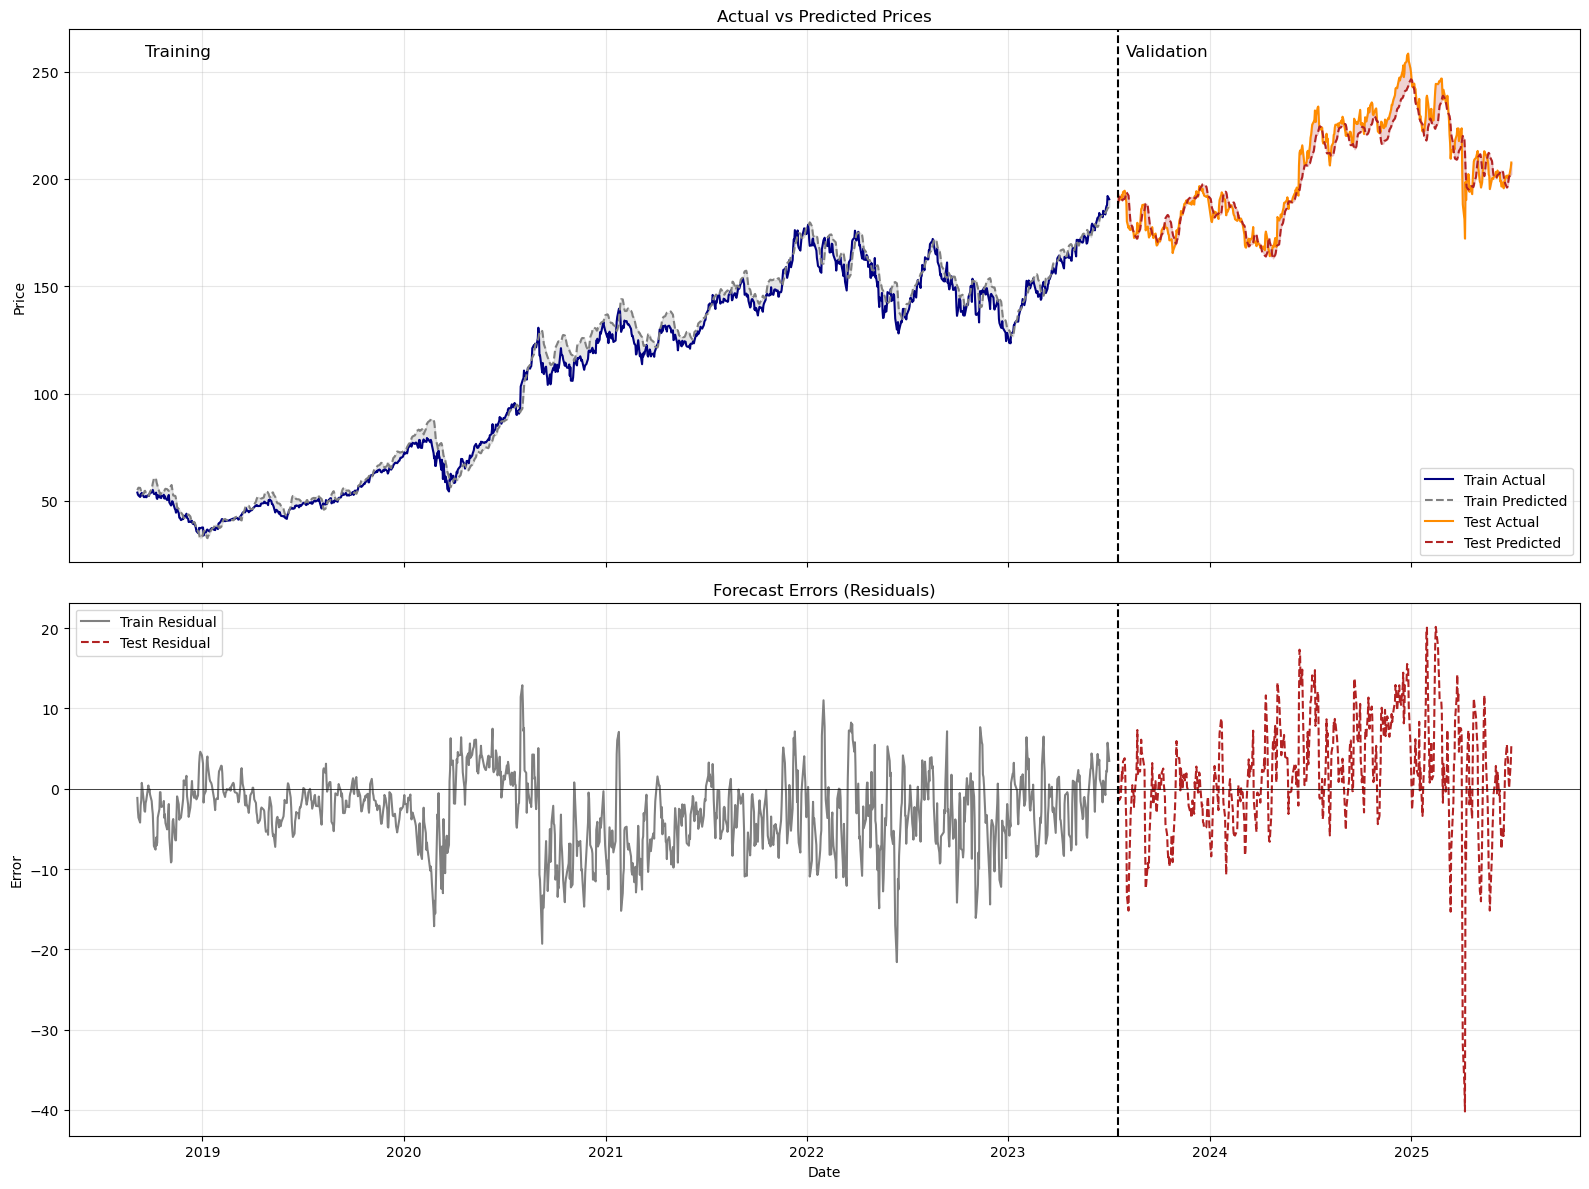

In [37]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# ====== ① Actual vs Predicted ======
ax1.plot(train_dates, train_actual, label='Train Actual', color='navy')
ax1.plot(train_dates, train_predicted, label='Train Predicted', color='gray', linestyle='--')
ax1.fill_between(train_dates, train_actual, train_predicted, color='gray', alpha=0.2)

ax1.plot(test_dates, test_actual, label='Test Actual', color='darkorange')
ax1.plot(test_dates, test_predicted, label='Test Predicted', color='firebrick', linestyle='--')
ax1.fill_between(test_dates, test_actual, test_predicted, color='firebrick', alpha=0.2)

ax1.axvline(split_date, color='black', linestyle='--', linewidth=1.5)
ax1.set_title('Actual vs Predicted Prices')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(alpha=0.3)

# Training / Validation Label
ypos = ax1.get_ylim()[0] + 0.95 * (ax1.get_ylim()[1] - ax1.get_ylim()[0])
ax1.text(train_dates[10], ypos, 'Training', fontsize=12)
ax1.text(test_dates[10], ypos, 'Validation', fontsize=12)


# ====== ② Forecast Errors ======
ax2.plot(train_dates, train_residual, color='gray', label='Train Residual')
ax2.plot(test_dates, test_residual, color='firebrick', linestyle='--', label='Test Residual')

ax2.axvline(split_date, color='black', linestyle='--', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Forecast Errors (Residuals)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


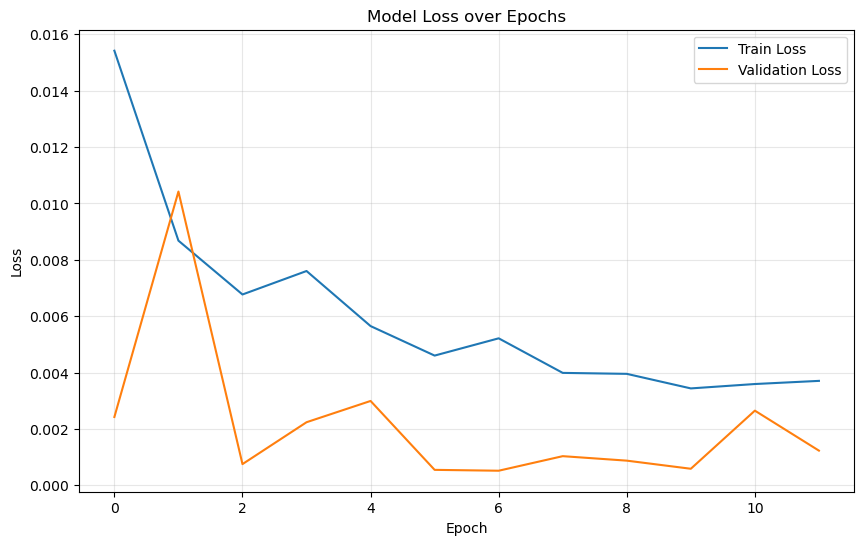

In [38]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

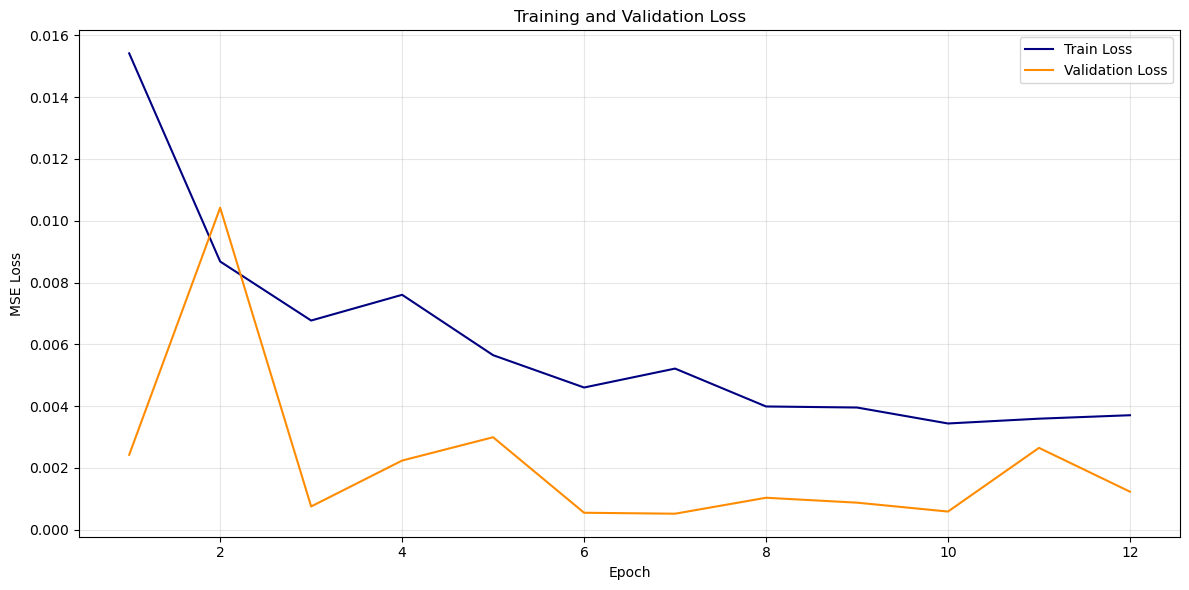

In [39]:
plt.figure(figsize=(12,6))
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], label='Train Loss', color='navy')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)

# Optional: 로그스케일
# plt.yscale('log')

plt.tight_layout()
plt.show()
